In [1]:
!pip install ultralytics
!pip install roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


# Export data dari roboflow

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="FpcVFBqGu4NssxOmazCm")
project = rf.workspace("bunga-rbhq8").project("dental-disease-detection-blc7j")
version = project.version(2)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dental-disease---detection-2 in yolo26:: 100%|██████████| 3525/3525 [00:00<00:00, 7440.50it/s]


# Training model YOLO26

In [3]:
from ultralytics import YOLO

# Load a dental-disease YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the dental example dataset for 50 epochs
results = model.train(data="/content/dental-disease---detection-2/data.yaml", epochs=50, imgsz=640)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental-disease---detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s

# Grafik hasil evaluasi training YOLO

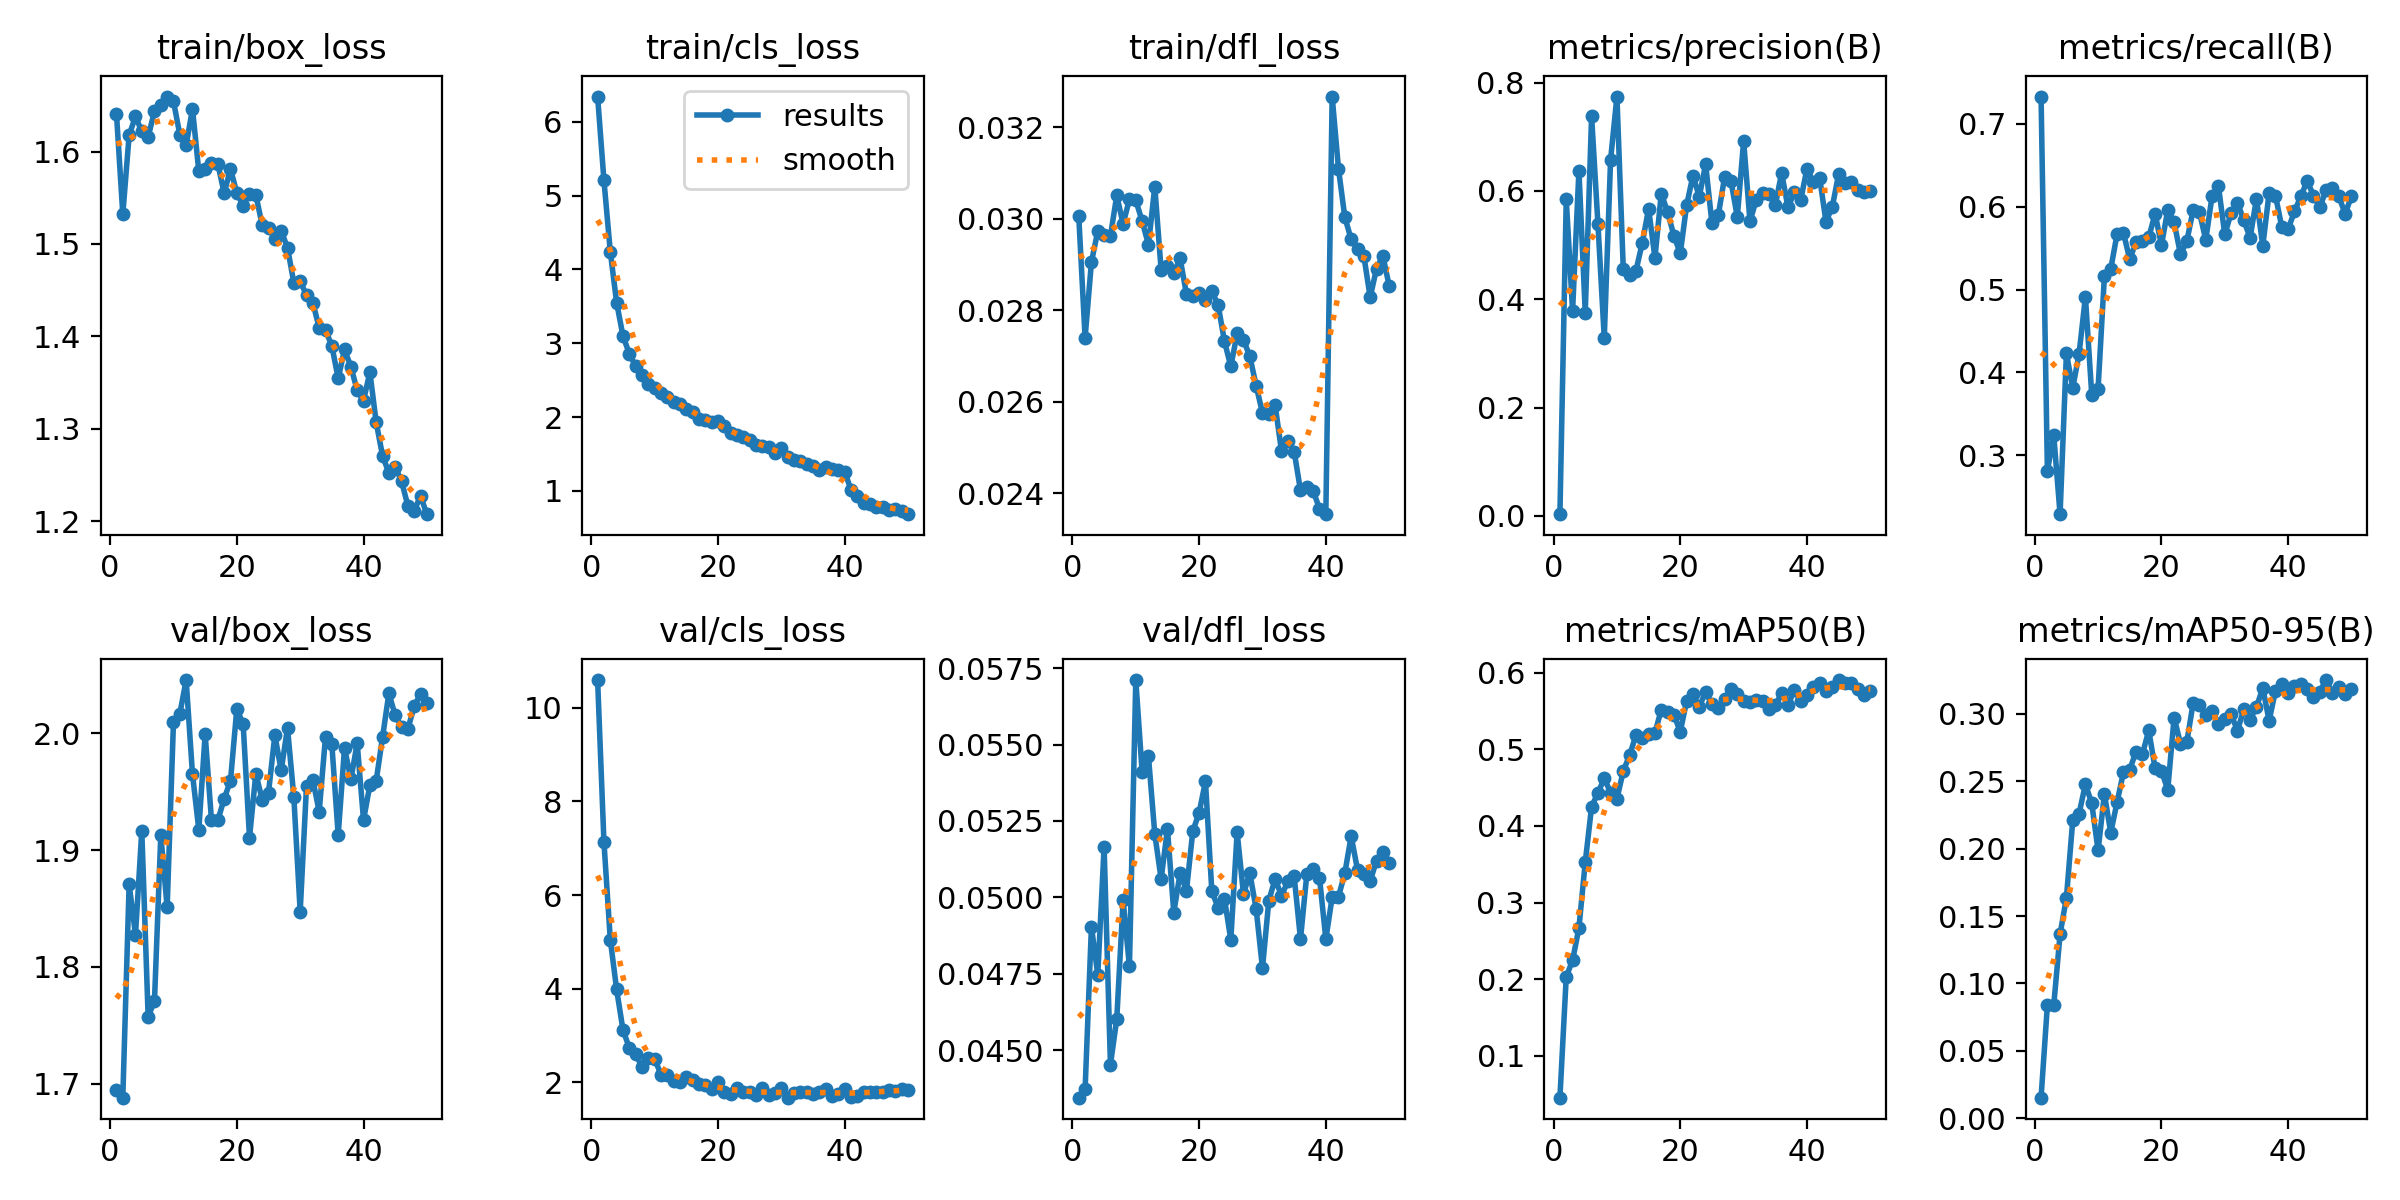

In [5]:
from IPython.display import Image

Image('/content/runs/detect/train/results.png', width=900)

# Hasil prediksi model pada data validasi

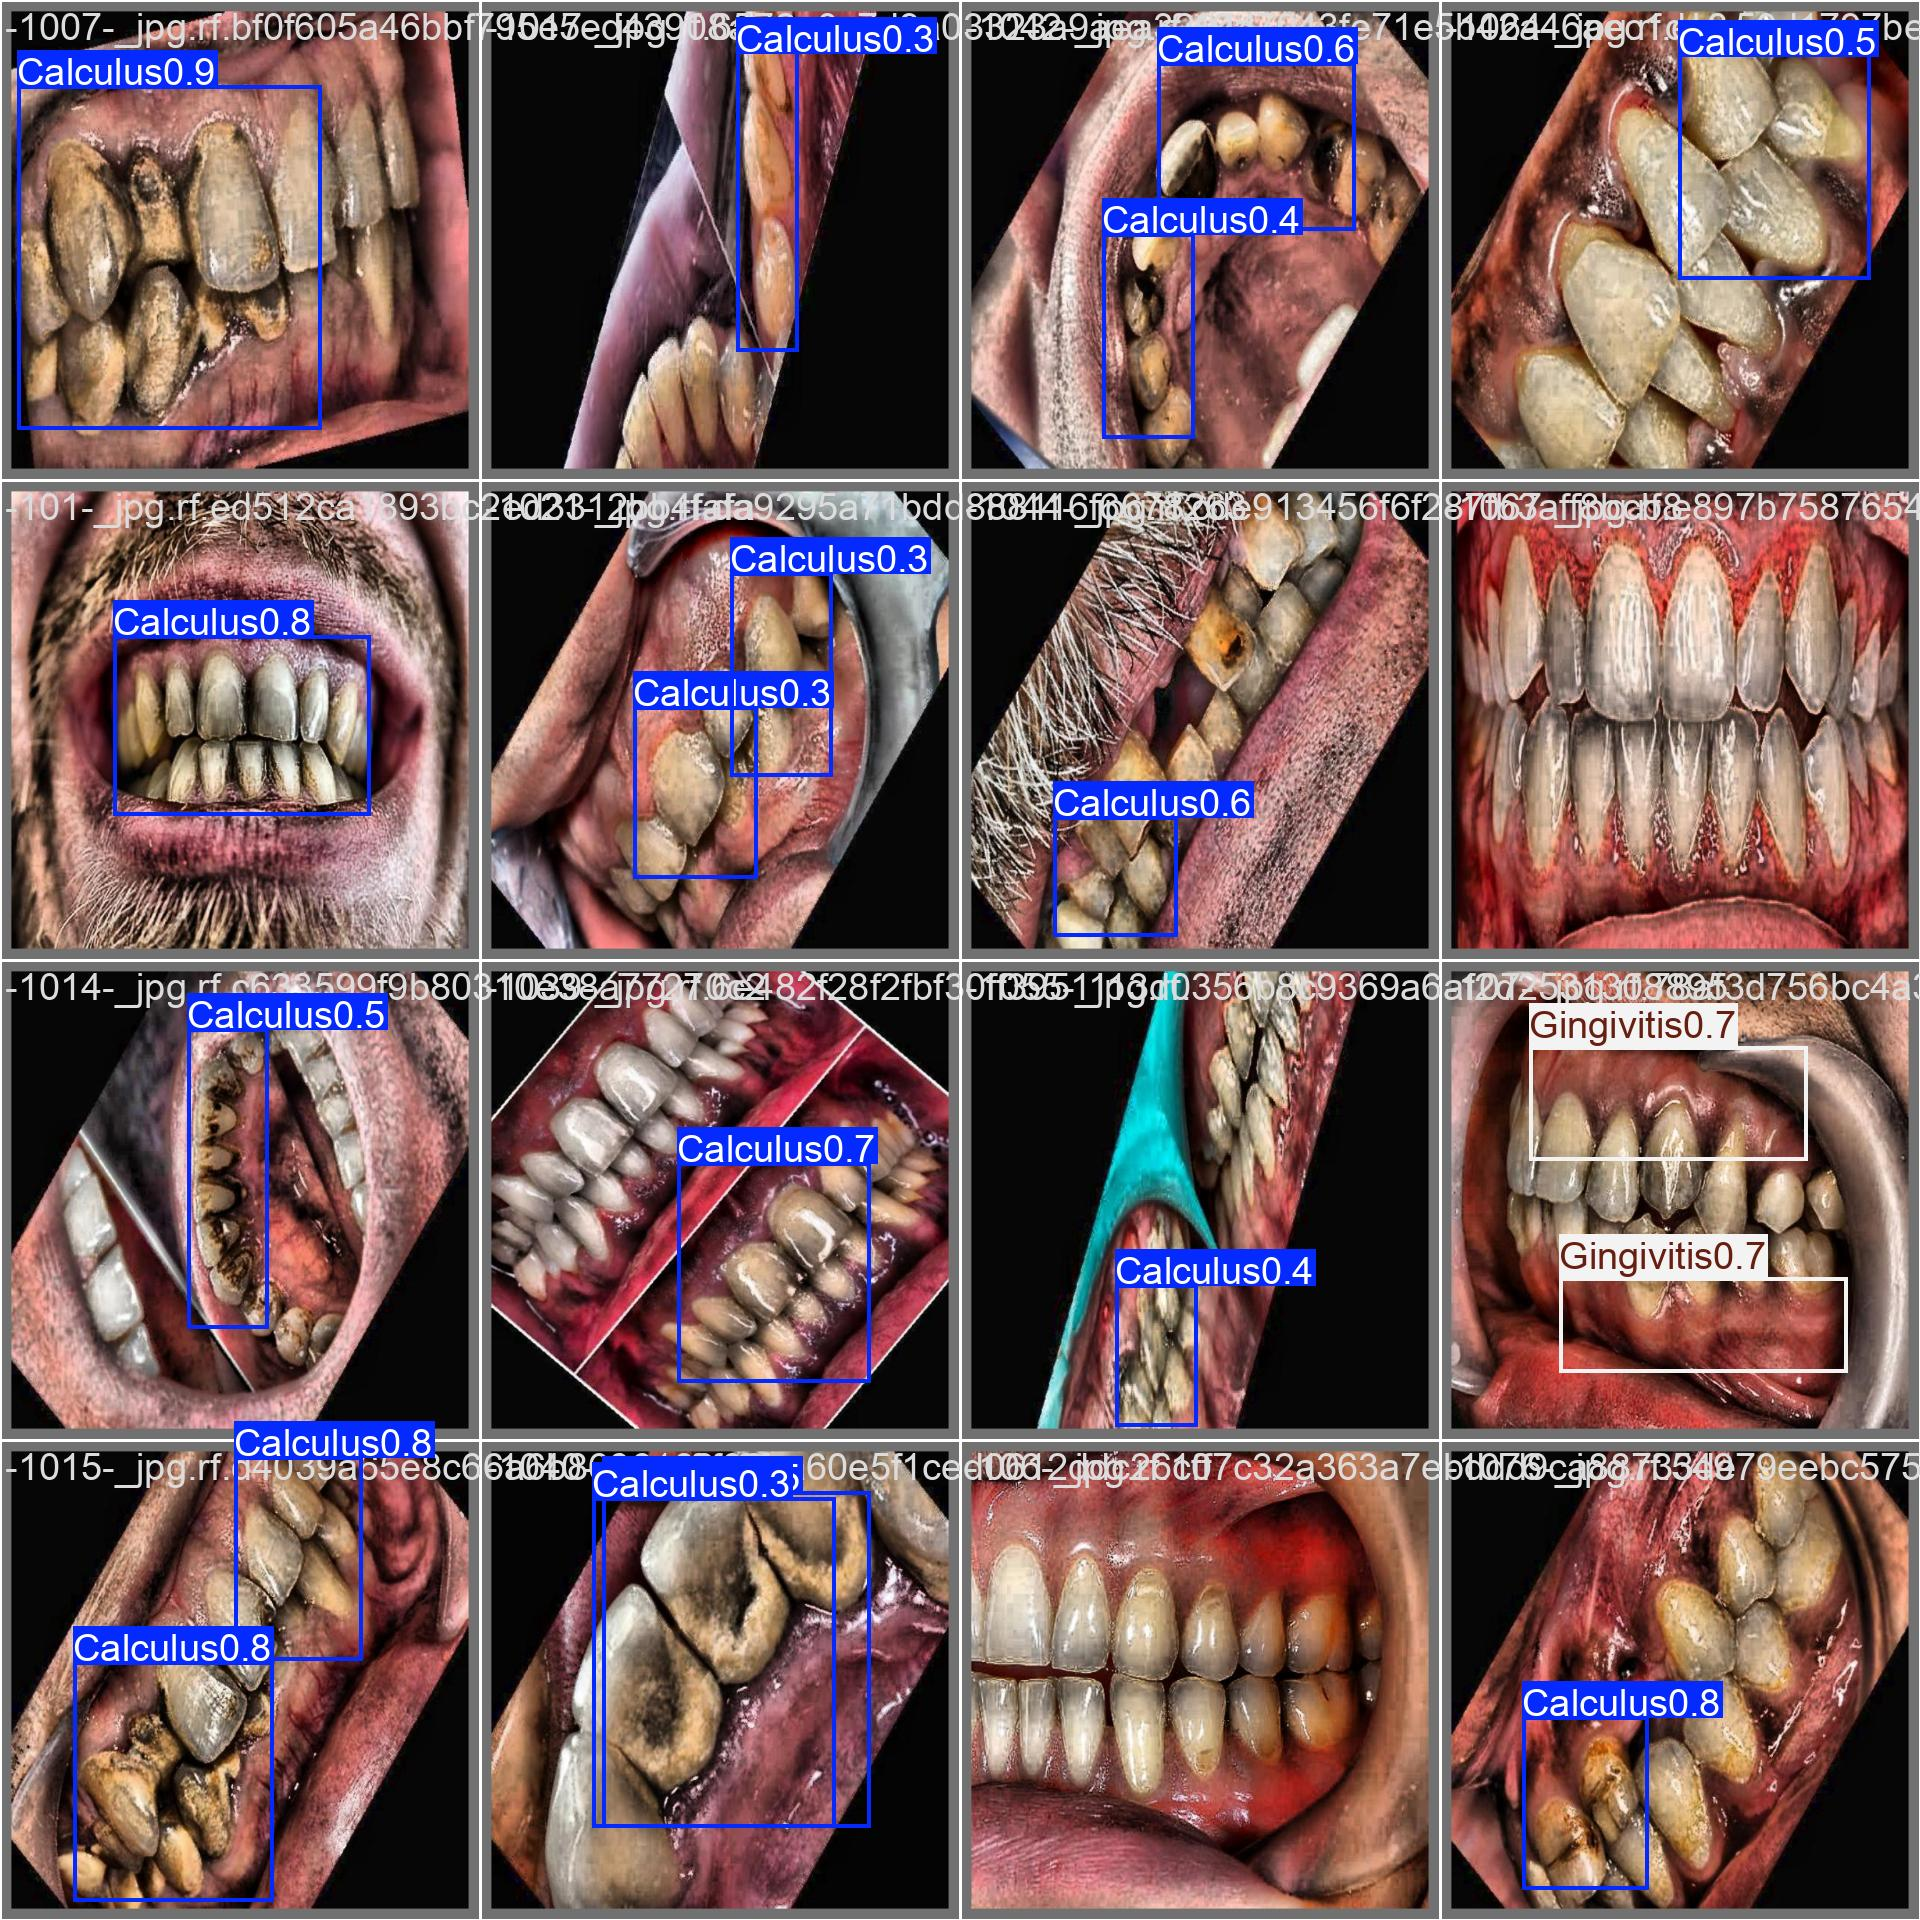

In [6]:
from IPython.display import Image

Image('/content/runs/detect/train/val_batch0_pred.jpg', width=900)

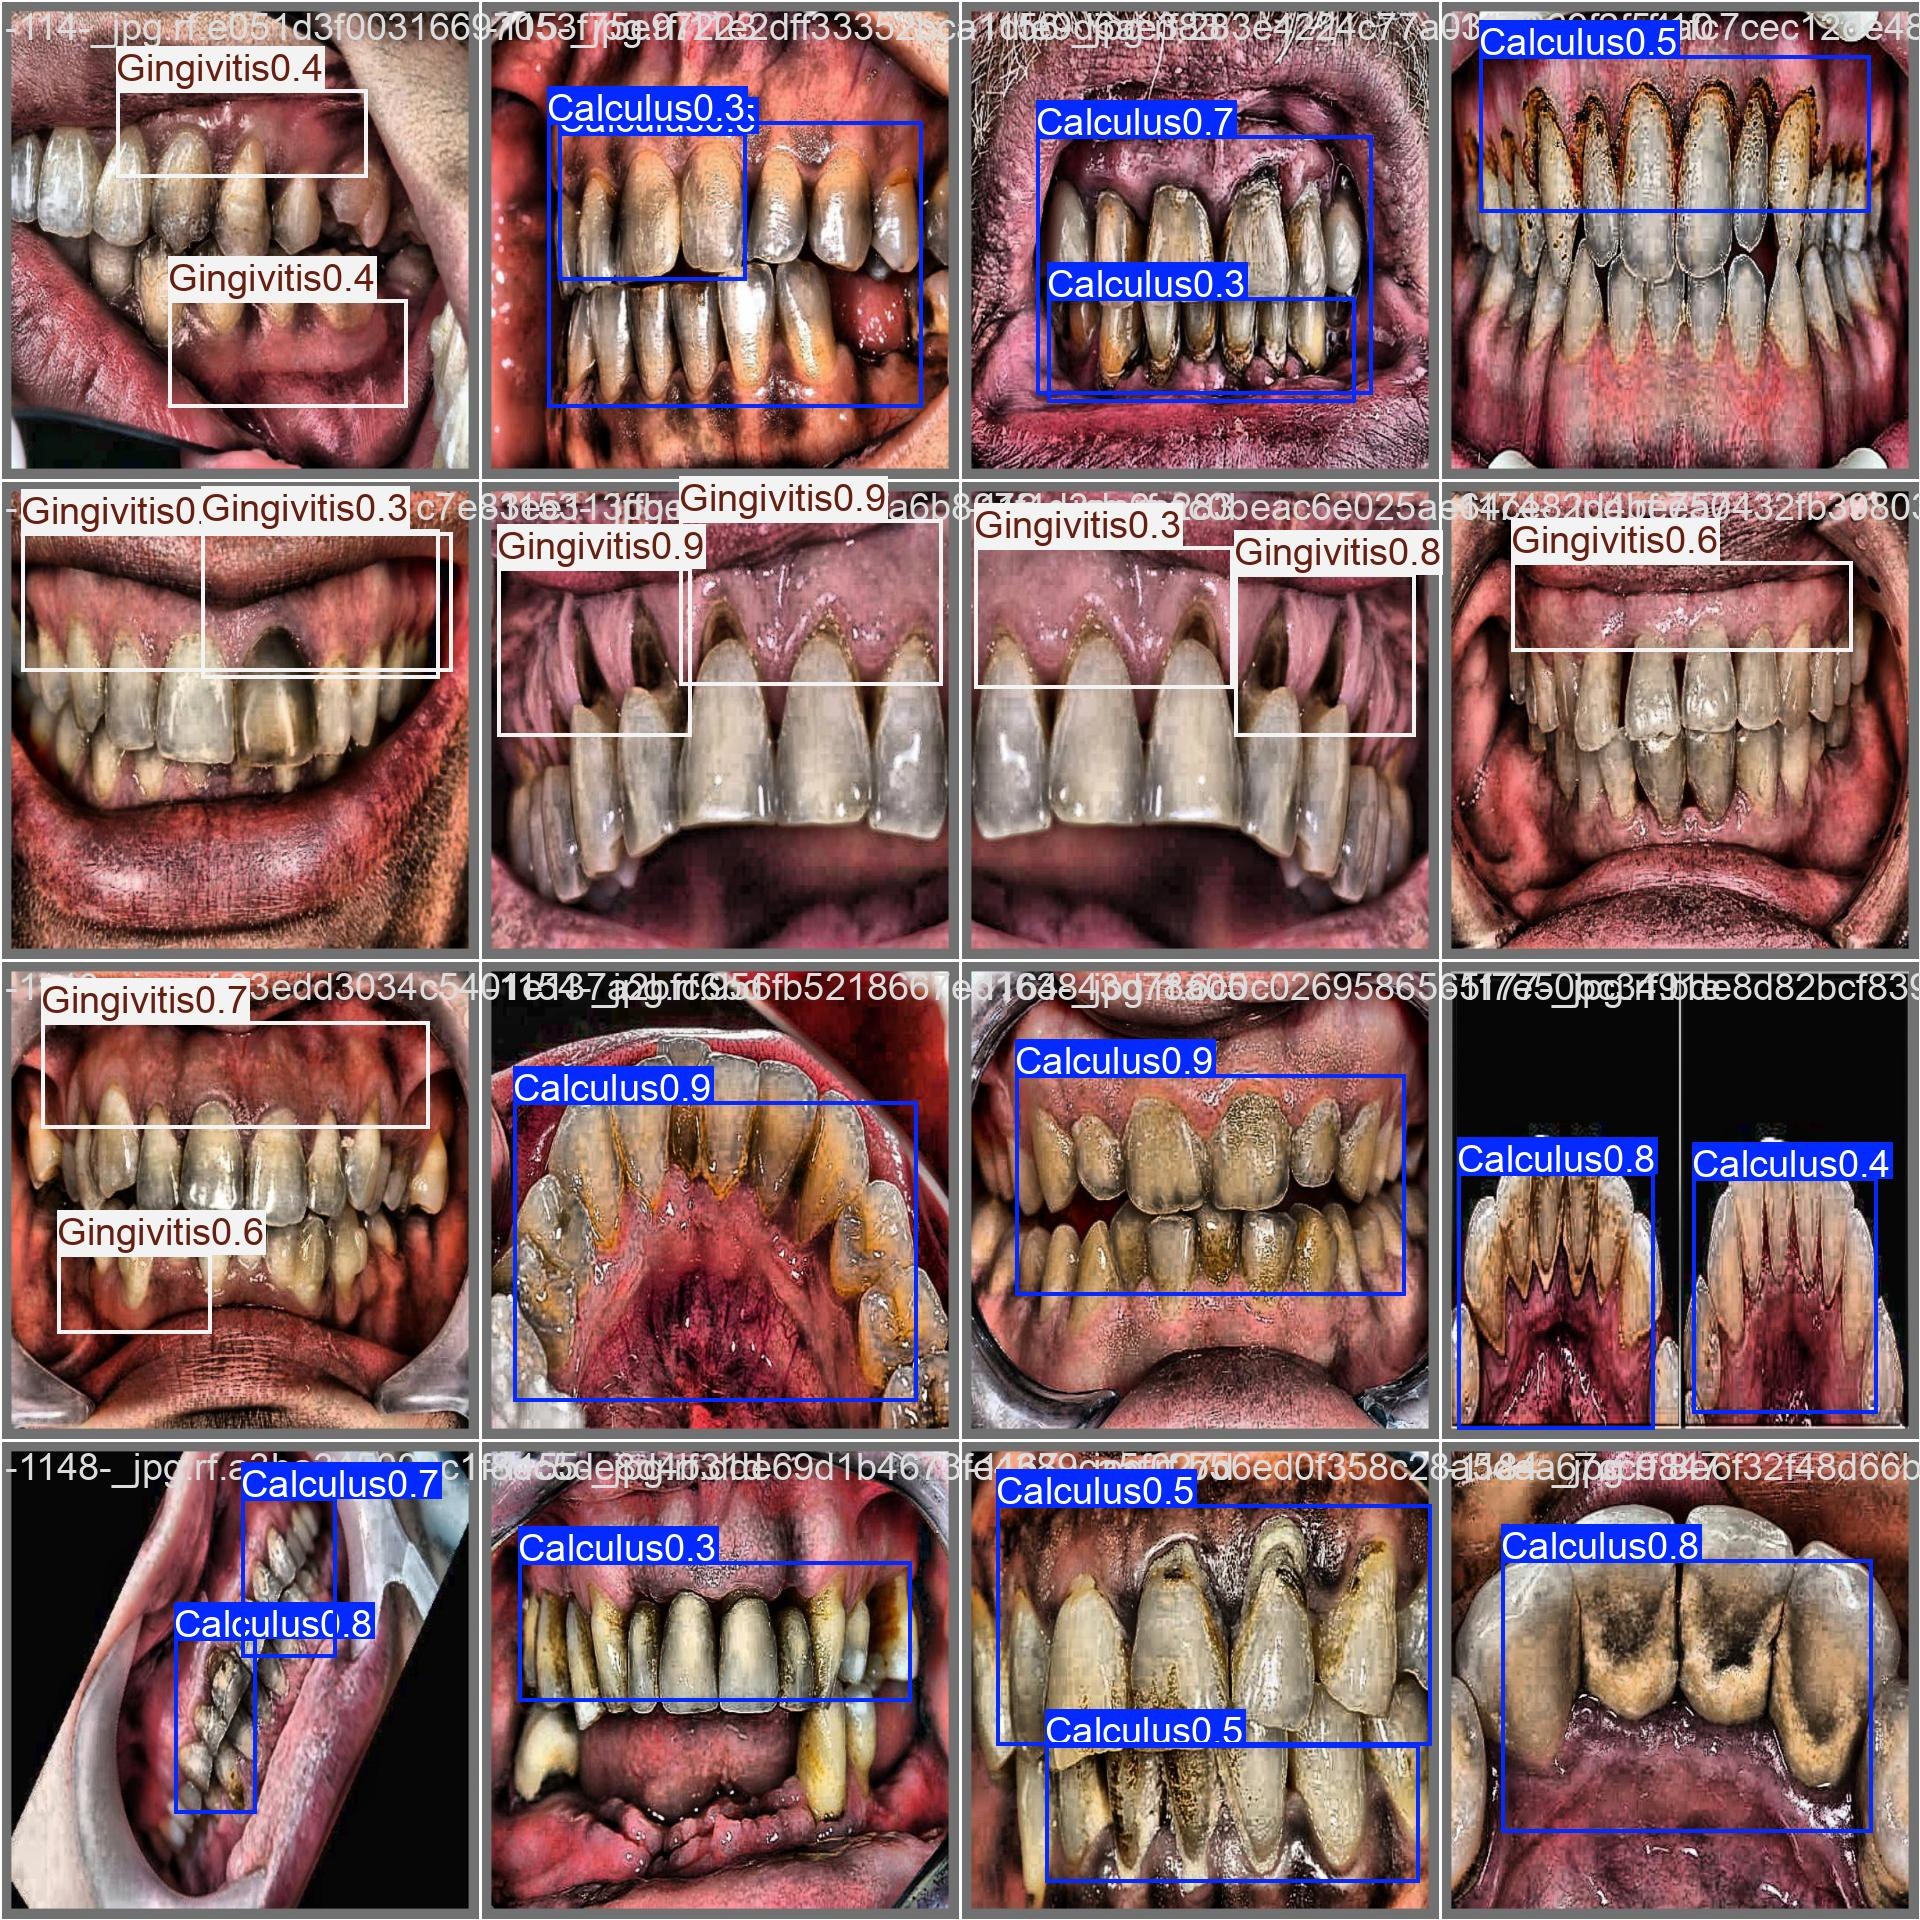

In [7]:
from IPython.display import Image

Image('/content/runs/detect/train/val_batch1_pred.jpg', width=900)

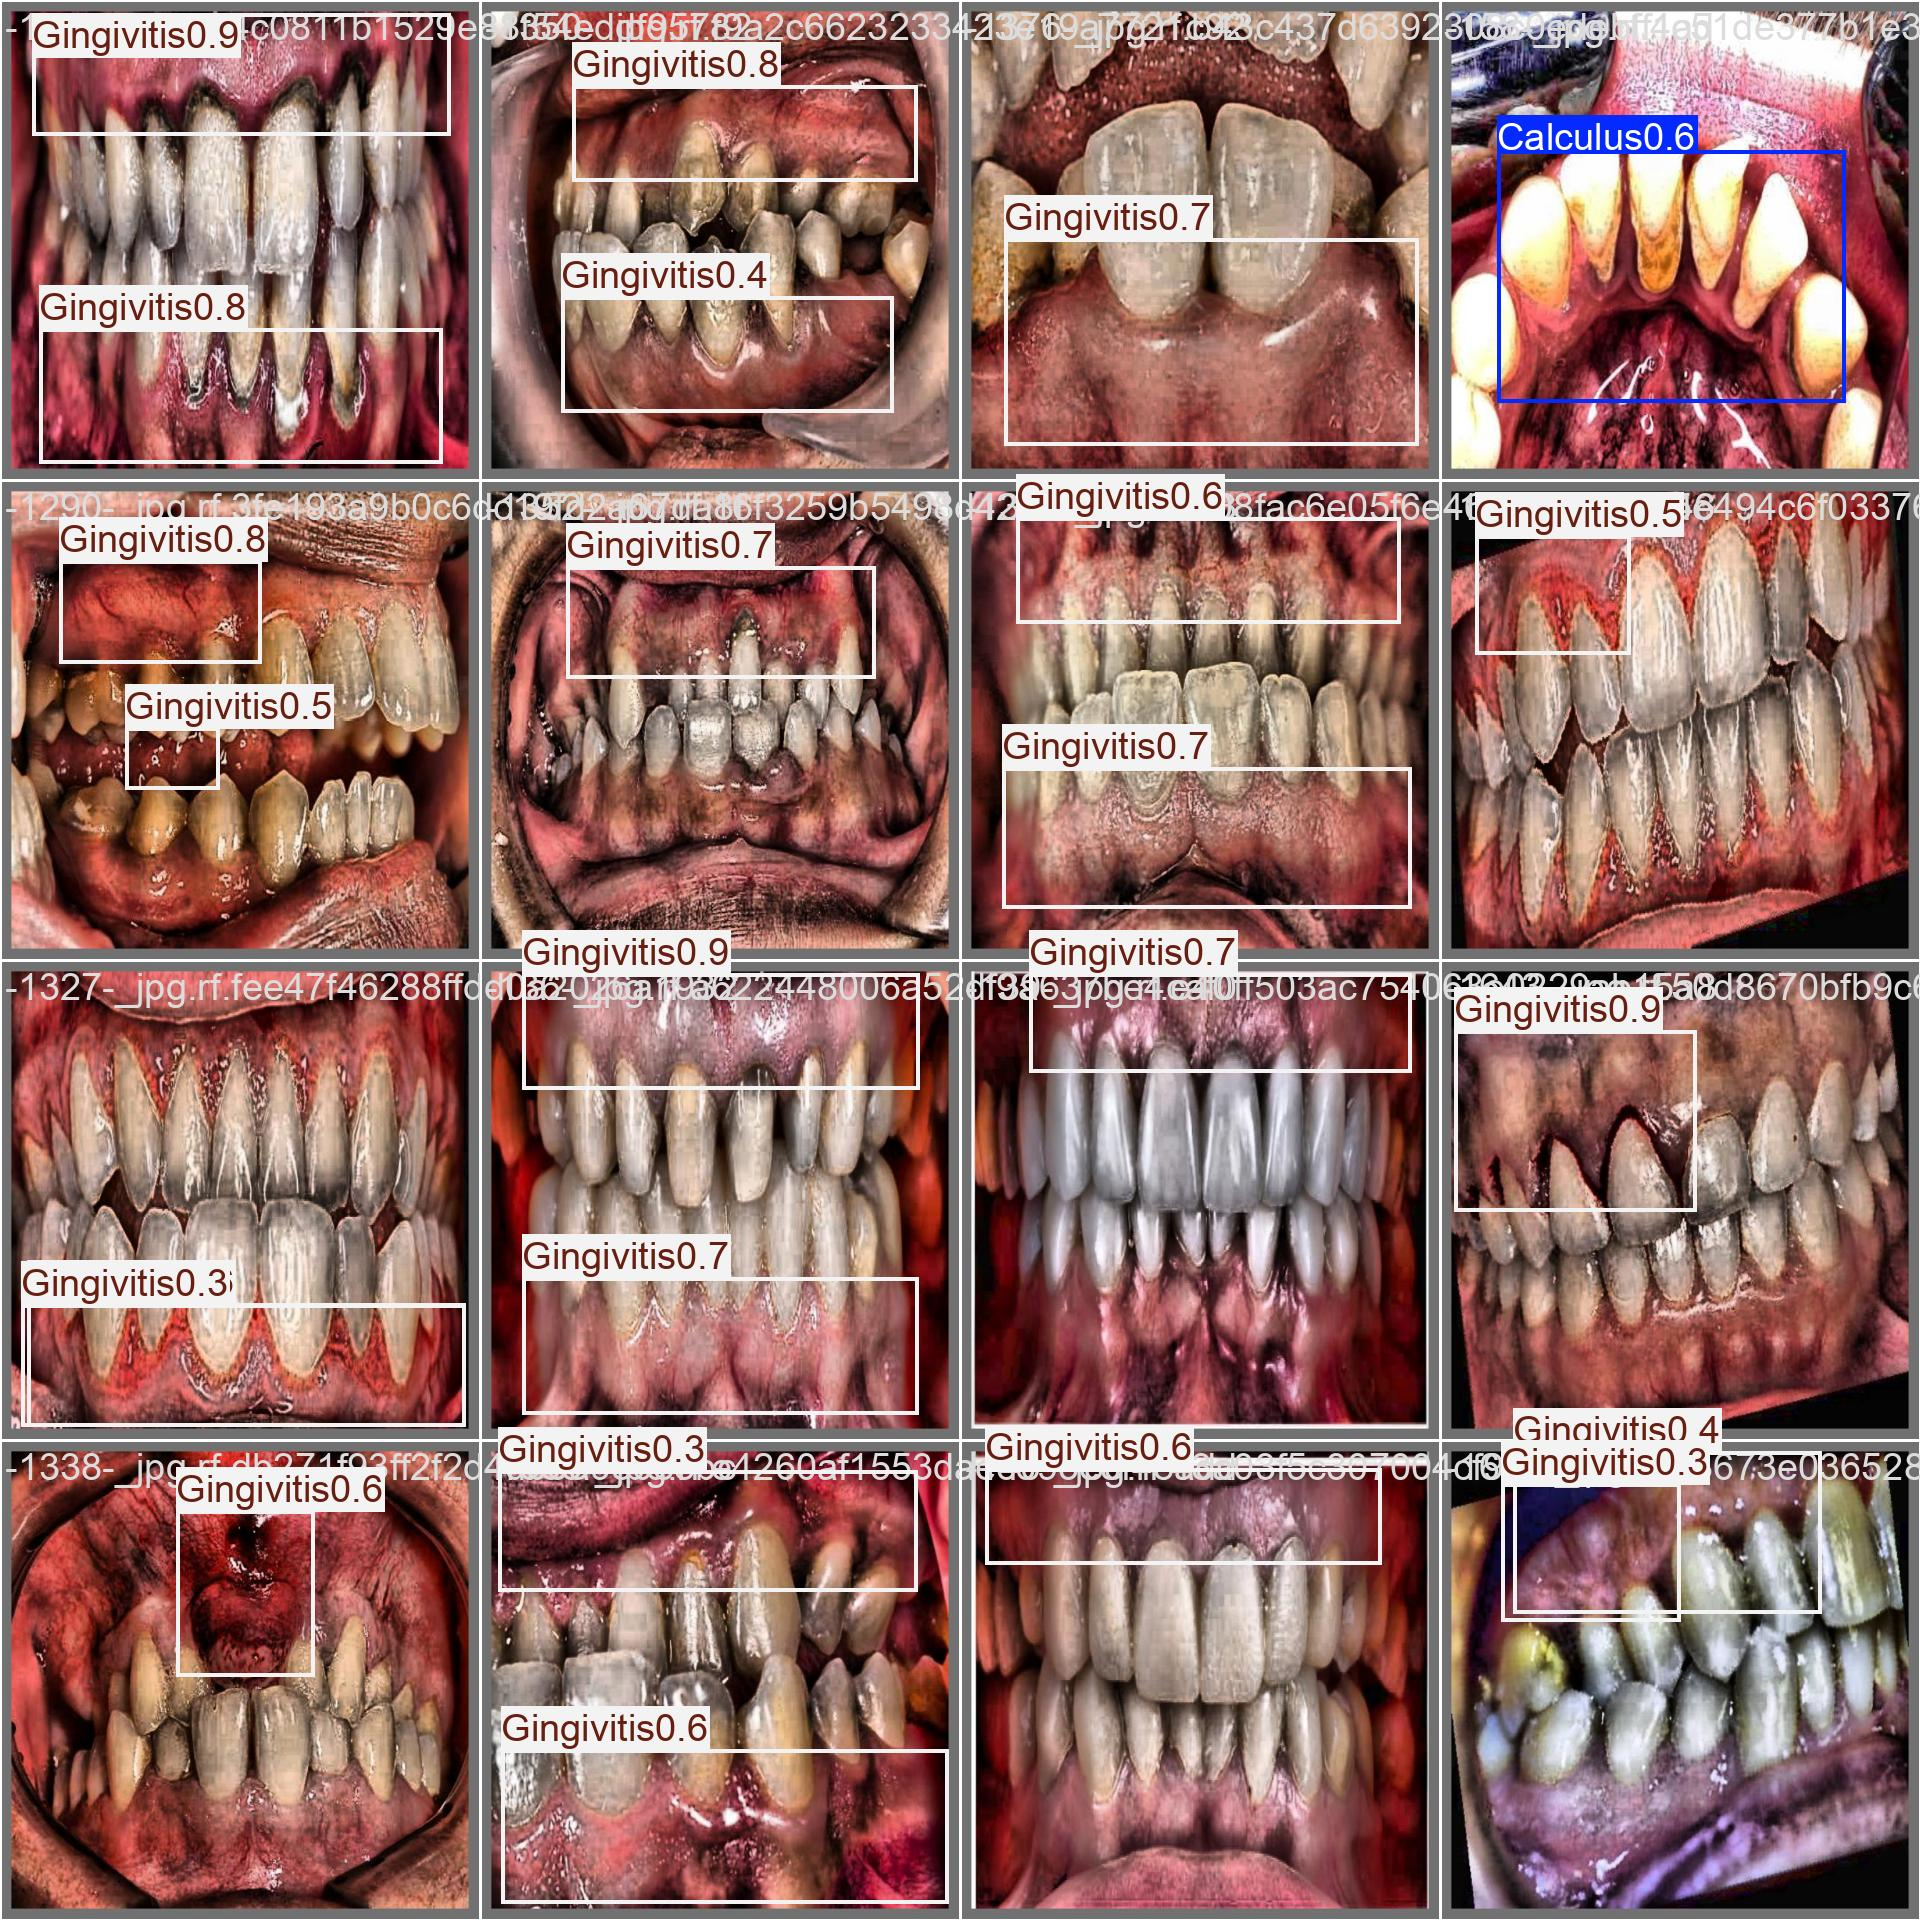

In [8]:
from IPython.display import Image

Image('/content/runs/detect/train/val_batch2_pred.jpg', width=900)

# Hasil prediksi dari model yolo yang sudah di olah

In [9]:
# After training, you can validate the model's performance on the validation set
results = model.val()

#Or perform prediction on new images or videos
results = model.predict("path/to/your/image.jpg")

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1616.1±722.2 MB/s, size: 43.2 KB)
val: Scanning /content/dental-disease---detection-2/valid/labels.cache... 148 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 148/148 51.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.3it/s 3.0s
                   all        148        214      0.615      0.623      0.587      0.325
              Calculus         39         64       0.42      0.375      0.287      0.103
                Caries         20         31      0.287      0.258      0.172     0.0498
            Gingivitis         41         72      0.556      0.505      0.496      0.203
               Healthy         40         40      0.915      0.975      0.987      0.496
                Plaque   

FileNotFoundError: path/to/your/image.jpg does not exist

ini sengaja di buat Eror untuk menunjukkan format penggunaan fungsi prediksi YOLO pada citra baru. Error ini tidak memengaruhi hasil pelatihan maupun validasi model yang telah berhasil dilakukan sebelumnya.

In [13]:
#Or perform prediction on new images or videos
results = model.predict("/content/dental-disease---detection-2/test/images/-10-_jpg.rf.cb54e361f37d10736afb66a409e7a39b.jpg", save=True, conf=0.2)


image 1/1 /content/dental-disease---detection-2/test/images/-10-_jpg.rf.cb54e361f37d10736afb66a409e7a39b.jpg: 640x640 1 Gingivitis, 12.4ms
Speed: 3.3ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [14]:
#Or perform prediction on new images or videos
results = model.predict("/content/dental-disease---detection-2/test/images/-1002-_jpg.rf.77893ef7de96b79aec0f09936a3987da.jpg", save=True, conf=0.2)


image 1/1 /content/dental-disease---detection-2/test/images/-1002-_jpg.rf.77893ef7de96b79aec0f09936a3987da.jpg: 640x640 1 Calculus, 1 Gingivitis, 19.1ms
Speed: 4.6ms preprocess, 19.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [15]:
#Or perform prediction on new images or videos
results = model.predict("/content/dental-disease---detection-2/test/images/train_image_-26-_1_jpg.rf.639a52df7e8a1b20c1aa05916d7f1e30.jpg", save=True, conf=0.2)


image 1/1 /content/dental-disease---detection-2/test/images/train_image_-26-_1_jpg.rf.639a52df7e8a1b20c1aa05916d7f1e30.jpg: 640x640 1 Healthy, 10.4ms
Speed: 3.2ms preprocess, 10.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
